In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Test/ODIR-5K/3552_right.jpg
/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Test/ODIR-5K/4711_left.jpg
/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Test/ODIR-5K/3534_right.jpg
/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Test/ODIR-5K/1911_right.jpg
/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Test/ODIR-5K/4691_left.jpg
/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Test/ODIR-5K/3588_right.jpg
/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Test/ODIR-5K/1701_right.jpg
/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Test/ODIR-5K/4739_right.jpg
/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Test/ODIR-5K/1343_right.jpg
/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Test/ODIR-5K/4661_left.jpg
/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Test/ODIR-5K/1685_left.jpg
/kaggle/input/dataset-for-different-

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define our example directories and files
IMAGE_SIZE = [150, 150]

train_datagen = ImageDataGenerator(rescale = 1./255.,
                                   validation_split=0.15,
                                   featurewise_center=False,
                                   samplewise_center=False,
                                   featurewise_std_normalization=False,
                                   samplewise_std_normalization=False,
                                   zca_whitening=False,
                                   rotation_range = 40,
                                   width_shift_range = 0.2,
                                   height_shift_range = 0.2,
                                   shear_range = 0.2,
                                   zoom_range = 0.2,
                                   horizontal_flip = True,
                                   vertical_flip=False
                                  )

# Note that the testing data should not be augmented!
test_datagen = ImageDataGenerator(rescale = 1.0/255.0)

# Flow training images in batches of 32 using train_datagen generator
train_generator = train_datagen.flow_from_directory('/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Train',
                                                    target_size = (150, 150),
                                                    batch_size = 64,
                                                    subset = "training",
                                                    class_mode = 'categorical',
                                                    #color_mode = 'grayscale'       # Comment
                                                   )

# Flow validation images in batches of 32 using train_datagen generator
validation_generator = train_datagen.flow_from_directory('/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Train',
                                                         target_size = (150, 150),
                                                         batch_size = 64,
                                                         subset = "validation",
                                                         class_mode = 'categorical',
                                                         #color_mode = 'grayscale'       # Comment
                                                        )

# Flow testing images in batches of 32 using test_datagen generator
test_generator = test_datagen.flow_from_directory('/kaggle/input/dataset-for-different-eye-disease/DATASET_101/Test',
                                                  target_size = (150, 150),
                                                  batch_size  = 64,
                                                  class_mode  = 'categorical',
                                                  #color_mode = 'grayscale',       # Comment
                                                  shuffle = False
                                                 )
                                 

2025-09-16 15:26:09.817589: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1758036369.870447     209 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1758036369.899067     209 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 7167 images belonging to 6 classes.
Found 1262 images belonging to 6 classes.
Found 1395 images belonging to 6 classes.


In [3]:
import tensorflow as tf

model = tf.keras.models.Sequential([
    # Note the input shape is the desired size of the image 150x150 with 3 bytes color
    # This is the first convolution
    tf.keras.layers.Conv2D(16, (7,7), activation='relu', input_shape=(150, 150, 3), padding="same", name="L1"),
    tf.keras.layers.MaxPooling2D(2, 2),
    # The second convolution
    tf.keras.layers.Conv2D(32, (7,7), activation='relu', name="L2"),
    tf.keras.layers.MaxPooling2D(2,2),
    # The third convolution
    tf.keras.layers.Conv2D(64, (7,7), activation='relu', name="L3"),
    tf.keras.layers.MaxPooling2D(2,2),
    # The fourth convolution
    #tf.keras.layers.Conv2D(128, (7,7), activation='relu', name="L4"),
    #tf.keras.layers.MaxPooling2D(2,2),

    # Flatten the results to feed into a DNN
    tf.keras.layers.Flatten(),

    # 256 neuron hidden layer
    tf.keras.layers.Dense(256, activation='relu', name="dense1" ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),
    # 128 neuron hidden layer
    tf.keras.layers.Dense(128, activation='relu', name="dense2" ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.25),

    # 6 neuron output layer
    tf.keras.layers.Dense(6, activation='softmax')
])

# Print the model summary
model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-09-16 15:26:17.983725: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Conv2D)                     │ (None, 150, 150, 16)   │         2,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Conv2D)                     │ (None, 69, 69, 32)     │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 34, 34, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Conv2D)                     │ (None, 28, 28, 64)     │       100,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 256)            │     3,211,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,374,630 (12.87 MB)

 Trainable params: 3,373,862 (12.87 MB)

 Non-trainable params: 768 (3.00 KB)

In [4]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import time

start = time.time()

# Compiling the CNN  # Set the training parameters
model.compile(optimizer = 'adam', loss = 'categorical_crossentropy',
              metrics = ['accuracy', #keras.metrics.Precision(), keras.metrics.Recall(),
                         #keras.metrics.SpecificityAtSensitivity(0.5),
                         #keras.metrics.SensitivityAtSpecificity(0.5)
                         ])

# Training the CNN on the Training set and evaluating it on the Test set
# Stop training if loss doesn't keep decreasing.
model_es = EarlyStopping(monitor = 'val_loss', min_delta = 1e-11, patience = 8, verbose = 1)
model_rlr = ReduceLROnPlateau(monitor = 'val_loss', factor = 0.5, patience = 3, verbose = 1)

# Automatically saves the best weights of the model, based on best val_accuracy
model_mcp = ModelCheckpoint(filepath = 'model_1_CNN.keras', monitor = 'val_accuracy',
                             save_best_only = True, verbose = 1)

history = model.fit(train_generator, validation_data = validation_generator,
                    epochs = 30, callbacks = [model_es, model_rlr, model_mcp]       # CHANGE number of epochs
                    #steps_per_epoch=62, validation_steps=6
                    )

end = time.time()
elapsed = end - start
print("Total Time:", elapsed)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5975 - loss: 1.5046
Epoch 1: val_accuracy improved from -inf to 0.89303, saving model to model_1_CNN.keras
112/112 ━━━━━━━━━━━━━━━━━━━━ 593s 5s/step - accuracy: 0.5987 - loss: 1.5005 - val_accuracy: 0.8930 - val_loss: 0.7193 - learning_rate: 0.0010
Epoch 2/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8918 - loss: 0.4700
Epoch 2: val_accuracy improved from 0.89303 to 0.91204, saving model to model_1_CNN.keras
112/112 ━━━━━━━━━━━━━━━━━━━━ 525s 5s/step - accuracy: 0.8919 - loss: 0.4694 - val_accuracy: 0.9120 - val_loss: 0.3238 - learning_rate: 0.0010
Epoch 3/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.9095 - loss: 0.3595
Epoch 3: val_accuracy did not improve from 0.91204
112/112 ━━━━━━━━━━━━━━━━━━━━ 611s 5s/step - accuracy: 0.9096 - loss: 0.3595 - val_accuracy: 0.8344 - val_loss: 0.5865 - learning_rate: 0.0010
Epoch 4/30
112/112 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9344 - loss: 0.2702
Epoch 

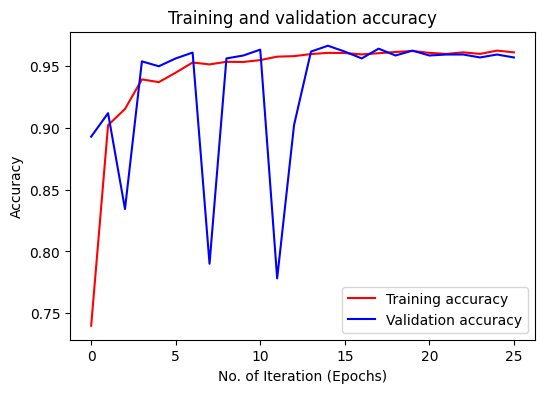

<Figure size 640x480 with 0 Axes>

In [8]:
import matplotlib.pyplot as plt

# accuracies
plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], 'r', label='Training accuracy')
plt.plot(history.history['val_accuracy'], 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.xlabel('No. of Iteration (Epochs)')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.savefig('train_val_acc.png')

In [6]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions using the model
Y_pred = model.predict(test_generator)  # Assuming test_generator yields batches of data
y_pred = np.argmax(Y_pred, axis=1)

# Print confusion matrix
print('Confusion Matrix')
print(confusion_matrix(test_generator.classes, y_pred))

# Print classification report
target_names = ['ACRIMA', 'Glaucoma', 'ODIR-5K', 'ORIGA', 'cataract', 'retina_disease']
print('Classification Report')
print(classification_report(test_generator.classes, y_pred, target_names=target_names, digits=4))

22/22 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step
Confusion Matrix
[[ 142    0    3    0    0    0]
 [   0   11    1   30   15    0]
 [   0    0 1000    0    0    0]
 [   0    0    1  132    0    0]
 [   0   15    2    0   13    0]
 [   0   17    0    0   13    0]]
Classification Report
                precision    recall  f1-score   support

        ACRIMA     1.0000    0.9793    0.9895       145
      Glaucoma     0.2558    0.1930    0.2200        57
       ODIR-5K     0.9930    1.0000    0.9965      1000
         ORIGA     0.8148    0.9925    0.8949       133
      cataract     0.3171    0.4333    0.3662        30
retina_disease     0.0000    0.0000    0.0000        30

      accuracy                         0.9305      1395
     macro avg     0.5635    0.5997    0.5779      1395
  weighted avg     0.9108    0.9305    0.9194      1395



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


22/22 ━━━━━━━━━━━━━━━━━━━━ 69s 3s/step
Classification Report
                precision    recall  f1-score   support

        ACRIMA     1.0000    0.9793    0.9895       145
      Glaucoma     0.2558    0.1930    0.2200        57
       ODIR-5K     0.9930    1.0000    0.9965      1000
         ORIGA     0.8148    0.9925    0.8949       133
      cataract     0.3171    0.4333    0.3662        30
retina_disease     0.0000    0.0000    0.0000        30

      accuracy                         0.9305      1395
     macro avg     0.5635    0.5997    0.5779      1395
  weighted avg     0.9108    0.9305    0.9194      1395



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


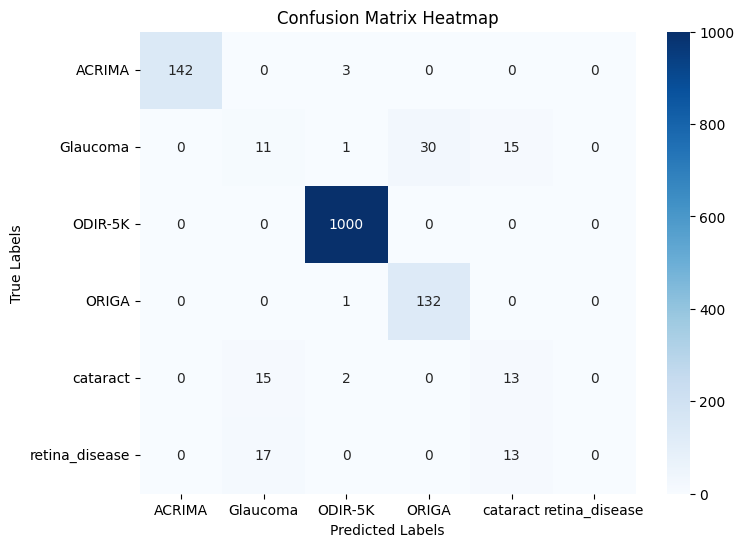

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Class names
target_names = ['ACRIMA', 'Glaucoma', 'ODIR-5K', 'ORIGA', 'cataract', 'retina_disease']

# Confusion Matrix
cm = confusion_matrix(test_generator.classes, y_pred)

print("Classification Report")
print(classification_report(test_generator.classes, y_pred, target_names=target_names, digits=4))

# Plot confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix Heatmap')
plt.show()


In [ ]:
import math
number_of_examples = len(test_generator.filenames)
number_of_generator_calls = math.ceil(number_of_examples / (1.0 * 64))
# 1.0 above is to skip integer division

test_labels = []
test_images = []

for i in range(0,int(number_of_generator_calls)):
    test_labels.extend(np.array(test_generator[i][1]))

for i in range(0,int(number_of_generator_calls)):
    test_images.extend(np.array(test_generator[i][0]))
    %matplotlib inline
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt
predictions = model.predict(test_generator)
new_labels = []
for i in range(0,1395):
  new_labels.append(np.argmax(predictions[i]))
newtest_labels = []
for i in range(0,1395):
  newtest_labels.append(np.argmax(test_labels[i]))
cm = confusion_matrix(y_true=newtest_labels, y_pred=new_labels)

 1/22 ━━━━━━━━━━━━━━━━━━━━ 16s 768ms/step

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_auc_score, roc_curve, auc

# Calculate accuracy score
score = metrics.accuracy_score(newtest_labels, new_labels)
print("Accuracy score: {}".format(score))

# Generate prediction probabilities
pred_prob = model.predict(test_generator)

# Calculate ROC AUC score
c = roc_auc_score(newtest_labels, pred_prob, multi_class='ovo')
print("AUC:", c)

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}
lw = 2
precision = {}
recall = {}

for i in range(6):
    fpr[i], tpr[i], _ = roc_curve(newtest_labels, pred_prob[:, i], pos_label=i)
    precision[i], recall[i], _ = roc_curve(newtest_labels, pred_prob[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(recall[i], precision[i], lw=2, label='class {}'.format(i))

plt.xlabel("recall")
plt.ylabel("precision")
plt.legend(loc="best")
plt.title("precision vs. recall curve")
plt.savefig('prc.png')
plt.show()

n_classes = 6

# First aggregate all false positive rates
all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))

# Then interpolate all ROC curves at these points
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

# Finally, average it and compute AUC
mean_tpr /= n_classes

fpr["macro"] = all_fpr
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

# Plot all ROC curves
plt.figure()

colors = cycle(['green', 'darkorange', 'cornflowerblue', 'yellow' ])
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=lw, label='ROC curve of class {0} (area = {1:0.4f})'
                                                       ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=lw)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Some extension of Receiver operating characteristic to multi-class')
plt.legend(loc="lower right")
plt.savefig('ssr.png')
plt.show()


In [ ]:
# Save the final model (if you want manually too)
model.save("model_1_CNN.keras")

# Load the model later
from tensorflow.keras.models import load_model
model = load_model("model_1_CNN.keras")


In [ ]:
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np

def get_img_array(img_path, size):
    img = tf.keras.preprocessing.image.load_img(img_path, target_size=size)
    array = tf.keras.preprocessing.image.img_to_array(img)
    array = np.expand_dims(array, axis=0)
    array = array / 255.0
    return array

def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        output = predictions[:, pred_index]

    grads = tape.gradient(output, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = np.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def save_and_display_gradcam(img_path, heatmap, cam_path="cam.jpg", alpha=0.4):
    img = cv2.imread(img_path)
    img = cv2.resize(img, (150, 150))
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_color, alpha, 0)
    cv2.imwrite(cam_path, superimposed)
    plt.imshow(superimposed[..., ::-1])
    plt.axis('off')
    plt.title("Grad-CAM")
    plt.show()


In [ ]:
def predict_image(image_path):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=(150, 150))
    x = tf.keras.preprocessing.image.img_to_array(img)
    x = np.expand_dims(x, axis=0) / 255.0
    pred = model.predict(x)
    class_index = np.argmax(pred)
    class_labels = list(train_generator.class_indices.keys())
    predicted_class = class_labels[class_index]
    print(f"Predicted Class: {predicted_class}")
    return predicted_class


In [ ]:
import shutil

# If saved as .keras
shutil.move("model_1_CNN.keras", "/kaggle/working/model_1_CNN.keras")

# If saved as .h5
# shutil.move("model_final.h5", "/kaggle/working/model_final.h5")
